## Project Overview
- **Datasets used:** Large-scale Twitter Sentiment Analysis dataset containing 224,994 tweets, labeled for sentiment. The dataset was filtered to a balanced subset 50,000 samples for efficient model training and evaluation.

- **Tools:**

Python
Pandas, NumPy – data handling and preprocessing

NLTK – tokenization, stopword handling, POS tagging, NER

Scikit-learn – TF-IDF, Logistic Regression, evaluation metrics

Hugging Face Transformers – pretrained transformer models

Matplotlib & Seaborn – data visualization

WordCloud – textual frequency visualization
- **Techniques:**

Text cleaning (lowercasing, URL & mention removal)

Tokenization using TweetTokenizer

Stopword removal with negation preservation

Slang normalization and noise filtering

Bag of Words (BoW) representation

TF-IDF with unigrams and bigrams

POS tagging and Named Entity Recognition (NER)

Train–test splitting with stratification

Model evaluation using Accuracy, Precision, Recall, F1-score, and Confusion Matrix
- **ML model:**

TF-IDF + Logistic Regression (baseline ML model)

BERT – Praveen-R/Tweet_sentiment_analysis_with_BERT

RoBERTa – cardiffnlp/twitter-roberta-base-sentiment

BERTweet – finiteautomata/bertweet-base-sentiment-analysis

## Problem Statement

Social-media mentions of organizations often contain unclear or rapidly shifting sentiment, making it difficult for organizations to quickly interpret public perception. We aim to improve sentiment detection by developing a text-classification model using a large Twitter sentiment dataset, targeting an F1-score of at least 70% to ensure balanced and reliable prediction performance.

## 1. Import Libraries

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import nltk
import inflect
import pandas as pd
import re
import string
import langid
import svgling
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk
from nltk import pos_tag
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
import torch
from transformers import pipeline
from nltk.tokenize import sent_tokenize
from nltk.tokenize import TreebankWordTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from nltk.tokenize import TweetTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.linear_model import LogisticRegression

### 2.Dataset

In [31]:
#pipline of the NLP Raw text where it's from the datset
splits = {'train': 'train.csv', 'test': 'test.csv'}
df_test = pd.read_csv("hf://datasets/gxb912/large-twitter-tweets-sentiment/" + splits["test"])
df_train = pd.read_csv("hf://datasets/gxb912/large-twitter-tweets-sentiment/" + splits["train"])

#Merged the dataset into one datset
merged_df = pd.concat([df_train, df_test], ignore_index=True)

In [32]:
#slang word inside the dataset
slang = pd.read_csv('slang.csv',index_col=False)

## 2. Exploratory Data Analysis (EDA)
### 2.1 Dataset Overview
#### Basic EDA
- head(): Displays the first five rows of the dataset.
- shape(): which return the shape of the dataset to know the numbers of columns and rows.
- describe() Generates summary statistics for numerical columns.
- info(): Provides a summary of the dataset.
- dtypes: Shows the data type of each column.

In [33]:
merged_df.head()

,sentiment,text
0,1,@tonigirl14 love you toooooo!! TG LOL Gngb
1,0,@jun6lee I told myself: Don't click on this li...
2,0,The man who rendered his voice to Mickey Mouse...
3,1,@Shontelle_Layne I think red would be nice. O...
4,0,@Silverlines - I guess. 'Cause one of her twee...


In [34]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224994 entries, 0 to 224993
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   sentiment  224994 non-null  int64 
 1   text       224994 non-null  object
dtypes: int64(1), object(1)
memory usage: 3.4+ MB


In [35]:
merged_df.describe()

,sentiment
count,224994.000000
mean,0.578491
std,0.493802
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [36]:
merged_df.shape

(224994, 2)

In [37]:
merged_df.dtypes

sentiment     int64
text         object
dtype: object

In [38]:
merged_df['sentiment'].unique()

array([1, 0])

In [39]:
merged_df['sentiment'].value_counts()

sentiment
1    130157
0     94837
Name: count, dtype: int64

## 2. Exploratory Data Analysis (EDA)
### 2.2 Dataset Visualizations

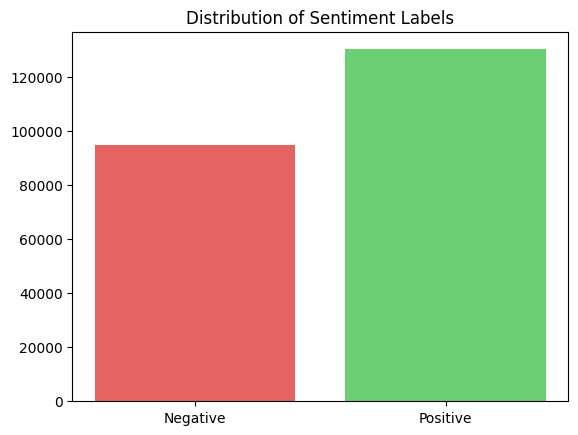

In [40]:
#the Class balance
counts = merged_df['sentiment'].value_counts()
plt.bar(['Negative','Positive'], [counts[0], counts[1]], color=['#e56363','#6ccf73'])
plt.title('Distribution of Sentiment Labels')
plt.show()

In [41]:
# examine the percentage of other language 
# get language id for each text
ids_langid = merged_df['text'].apply(langid.classify)
print(ids_langid[0]) 
# get just the language label
langs = ids_langid.apply(lambda tuple: tuple[0])
# unique languages present 
print(f"no of unique languages estimated: {len(langs.unique())}")
print('unique languages:')
print(langs.unique()) 
print(f"percentage of English: {(sum(langs=='en')/len(langs))*100}")

('en', 9.061840057373047)
no of unique languages estimated: 67
unique languages:
['en' 'pl' 'it' 'de' 'nl' 'fr' 'cy' 'mt' 'et' 'es' 'ro' 'hu' 'xh' 'da'
 'br' 'tr' 'sl' 'pt' 'la' 'id' 'af' 'sw' 'fi' 'sv' 'cs' 'eu' 'ms' 'hr'
 'no' 'tl' 'rw' 'lb' 'bs' 'ca' 'sk' 'lt' 'sq' 'lv' 'az' 'ga' 'nn' 'ht'
 'wa' 'an' 'jv' 'el' 'eo' 'zu' 'zh' 'vi' 'nb' 'fo' 'ka' 'mg' 'ku' 'qu'
 'gl' 'oc' 'ky' 'vo' 'he' 'hy' 'is' 'se' 'ar' 'si' 'lo']
percentage of English: 95.23898415068847


In [42]:
#checking the percentage of the English Language
langs = langs.dropna()

#Counts + percentages per language
lang_counts = langs.value_counts()
lang_pct = (lang_counts / len(langs)) * 100

print(f"Total rows: {len(langs):,}")
print(f"Unique languages: {lang_counts.size}")
print(f"English %: {lang_pct.get('en', 0):.2f}%")

# Conuts the number of the English vs Non English
en_count = int(lang_counts.get('en', 0))
non_en_count = len(langs) - en_count

Total rows: 224,994
Unique languages: 67
English %: 95.24%


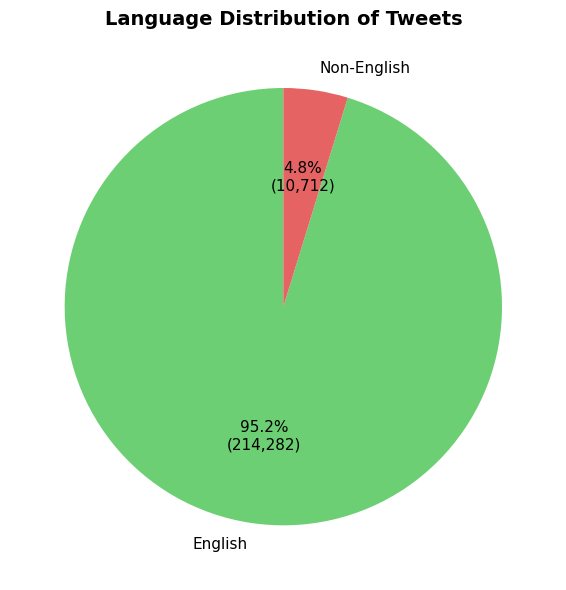

In [43]:
#Plot A: English vs Non-English (pie)
plt.figure(figsize=(6, 6))

colors = ['#6ccf73','#e56363']  # green / soft red

plt.pie(
    [en_count, non_en_count],
    labels=["English", "Non-English"],
    autopct=lambda p: f"{p:.1f}%\n({int(p/100*(en_count+non_en_count)):,})",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 11}
)

plt.title("Language Distribution of Tweets", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


In [44]:
#visualizaion the Tweet
def tweet(data, m, n):
    for i in range(n - m + 1):
        print('-', m+1, '------------------------------------------------------------------------------------------')
        print(data.iloc[m])
        m += 1

tweet(merged_df['text'], 0, 10)

- 1 ------------------------------------------------------------------------------------------
@tonigirl14 love you toooooo!! TG  LOL Gngb
- 2 ------------------------------------------------------------------------------------------
@jun6lee I told myself: Don't click on this link. But I just did. Booohooo 
- 3 ------------------------------------------------------------------------------------------
The man who rendered his voice to Mickey Mouse expired. He was 62 years old!  i'm a Mickey fan!
- 4 ------------------------------------------------------------------------------------------
@Shontelle_Layne I think red would be nice.  Or maybe you could do a mix of red and black. 
- 5 ------------------------------------------------------------------------------------------
@Silverlines - I guess. 'Cause one of her tweets says she is confused. 
- 6 ------------------------------------------------------------------------------------------
Have to go home in awhile. Goodbye, internet.  I w

## 3. Data Preprocessing

In [45]:
df=merged_df.copy()

In [46]:
# Assign the language to dataframe
merged_df['language'] = langs 
# query for only english tweets 
df = merged_df.loc[merged_df["language"] == "en"].copy()
df.shape

(214282, 3)

In [47]:
# Create a translation table to remove punctuation characters
translator = str.maketrans('', '', string.punctuation)

# Remove rows with missing slang acronyms or expansions
slang = slang.dropna(subset=["acronym", "expansion"]).copy()
# Normalize slang entries (lowercase and trim spaces)
slang["acronym"]   = slang["acronym"].astype(str).str.lower().str.strip()
slang["expansion"] = slang["expansion"].astype(str).str.lower().str.strip()
# Convert slang dataframe into a lookup dictionary
slang_dict = dict(zip(slang["acronym"], slang["expansion"]))

def replace_slang(text: str, slang_dict: dict) -> str:
    if not slang_dict:
        return text
    pattern = re.compile(r"\b(" + "|".join(map(re.escape, slang_dict.keys())) + r")\b")
    return pattern.sub(lambda m: slang_dict[m.group(1)], text)

def normalize_contractions(text):
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"'m\b", " am", text)
    text = re.sub(r"'re\b", " are", text)
    text = re.sub(r"'s\b", " is", text)
    text = re.sub(r"'ll\b", " will", text)
    text = re.sub(r"'ve\b", " have", text)
    text = re.sub(r"'d\b", " would", text)
    return text

def normalize_twitter_shorthand(text):
    text = re.sub(r"\b2day\b", " today ", text)
    text = re.sub(r"\b2moro\b|\b2mrw\b", " tomorrow ", text)
    text = re.sub(r"\b2nite\b|\b2night\b", " tonight ", text)
    text = re.sub(r"\bu\b", " you ", text)
    return text

def normalize_elongation(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def remove_urls(text):
    return re.sub(r"http\S+|www\.\S+", "", text)
def remove_mentions(text):
    return re.sub(r"@\w+", "", text)
def remove_hashtag(text):
    return re.sub(r"#(\w+)", r"\1", text)
def remove_digits(text):
    return re.sub(r"\d+", "", text)
def remove_punct(text):
    return text.translate(translator)
def remove_ws(text):  
    return " ".join(text.split())

df["ctext"] = (
    df["text"].fillna("").astype(str)# he LogisticRegression
    .apply(remove_urls)# Remove URLs
    .apply(remove_mentions)# Remove user mention
    .apply(lambda x: replace_slang(x, slang_dict))# Expand slang/acronyms
    .apply(normalize_contractions)# Expand contractions
    .apply(normalize_twitter_shorthand)# Normalize Twitter shorthand
    .apply(normalize_elongation)# Normalize elongated words
    .apply(remove_digits)# Remove digits
    .apply(remove_hashtag)# Clean hashtags
    .apply(remove_punct)# Remove punctuation
    .apply(remove_ws) # Normalize whitespace
)

In [48]:
# Initialize NLTK TweetTokenizer with Twitter-specific settings
tt = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
# Tokenize cleaned tweet text into individual word tokens
df["tokens"] = df["ctext"].fillna("").astype(str).apply(tt.tokenize)

In [49]:
#applying the the function
df["tokens"].apply(type).value_counts()

tokens
<class 'list'>    214282
Name: count, dtype: int64

In [50]:
#remove all the stop words
stop_words = set(stopwords.words("english"))
neg = {"no", "not", "nor", "never", "n't"}
stop_words = stop_words - neg

def remove_stopwords(tokens):
    return [t for t in tokens if t.lower() not in stop_words]

df["ctokens"] = df["tokens"].apply(remove_stopwords)

In [51]:
#remove all words that might cause noise
#the NO and NOT kept
BLACKLIST = {
    "gngb","tg","oppa","st","u",
    "lol","lmao","omg","idk","smh","tbh","btw","ugh","wow","boohoo",
    "rt","followfriday","&amp;","amp"
}
KEEP_ALWAYS = {"no","not"}

PUNCT_STRIP = string.punctuation + "…’“”–—"

def normalize_token(t: str) -> str:
    t = str(t).lower().strip(PUNCT_STRIP)
    t = re.sub(r"^[^a-z]+|[^a-z]+$", "", t)   # strips emojis/punct at edges
    return t

def filter_noise(tokens):
    out = []
    for t in tokens:
        t = normalize_token(t)
        if not t:
            continue
        if t in KEEP_ALWAYS:
            out.append(t)
            continue
        if t in BLACKLIST:
            continue
        if re.fullmatch(r"[a-z]+", t) and len(t) >= 3:
            out.append(t)
    return out
df["ftokens"] = df["ctokens"].apply(filter_noise)


In [52]:
clean_words = [w for toks in df["ftokens"] for w in toks]
Counter(clean_words).most_common(15)

[('not', 39961),
 ('good', 14463),
 ('get', 12760),
 ('like', 12546),
 ('no', 10461),
 ('laughing', 9677),
 ('day', 9487),
 ('love', 9457),
 ('know', 9193),
 ('loud', 8985),
 ('one', 8052),
 ('thanks', 7590),
 ('going', 7469),
 ('got', 7468),
 ('really', 7424)]

In [53]:
# Convert the list of filtered tokens in each row into a single space-separated string
df["ftext"] = df["ftokens"].apply(lambda toks: " ".join(toks))

In [54]:
#POS (Part-of-Speech)
def named_entity_recognition(pos_tags):
    return ne_chunk(pos_tags)

In [55]:
#apply the function
df["POS_tags"] = df["ftokens"].apply(pos_tag)

In [56]:
df["POS_tags"].head()

0                                         [(love, NN)]
1    [(told, VBD), (not, RB), (click, JJ), (link, NN)]
2    [(man, NN), (rendered, VBD), (voice, NN), (mic...
3    [(think, NN), (red, VBD), (would, MD), (nice, ...
4    [(guess, NN), (cause, NN), (one, CD), (tweets,...
Name: POS_tags, dtype: object

- Tweet [1]


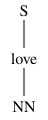

- Tweet [2]


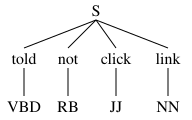

- Tweet [3]


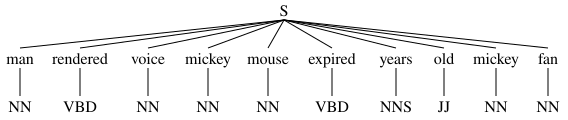

- Tweet [4]


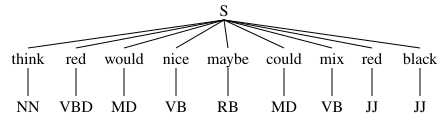

- Tweet [5]


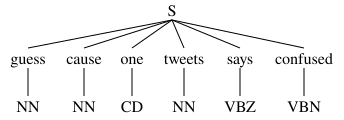

In [57]:
#show the top 5 rows after applying the NER
for i in range(5):
    print(f"- Tweet [{i+1}]")
    display(named_entity_recognition(df.loc[i, "POS_tags"]))

In [58]:
bow_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.9
)

X_bow = bow_vectorizer.fit_transform(df["ctext"])
y = df["sentiment"]
print("BoW matrix shape:", X_bow.shape)
print("Vocab size:", len(bow_vectorizer.get_feature_names_out()))
print("First 20 vocab words:", bow_vectorizer.get_feature_names_out()[:20])

BoW matrix shape: (214282, 36825)
Vocab size: 36825
First 20 vocab words: ['aa' 'aaah' 'aages' 'aah' 'aahh' 'aand' 'aargh' 'aaron' 'aaw' 'aaww' 'ab'
 'abandoned' 'abby' 'abc' 'aberdeen' 'ability' 'ability to' 'abit' 'able'
 'able to']


In [59]:
len(bow_vectorizer.get_feature_names_out())

36825

In [67]:
neg = {"no", "not", "nor", "never"}
stop_words = list(set(stopwords.words("english")) - neg)
tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b[a-z]{2,}\b",
    stop_words=stop_words,
    ngram_range=(1,2),
    min_df=10,
    max_df=0.9,
    sublinear_tf=True
)

tfidf_t = tfidf.fit_transform(df["ctext"])
y = df["sentiment"]
print(tfidf_t.shape)
print(tfidf.get_feature_names_out()[:20])


(214282, 20625)
['aa' 'aaah' 'aages' 'aah' 'aahh' 'aand' 'aargh' 'aaron' 'aaw' 'aaww' 'ab'
 'abandoned' 'abby' 'abc' 'aberdeen' 'ability' 'abit' 'able' 'able afford'
 'able get']


In [68]:
tfidf_t.shape

(214282, 20625)

In [69]:
tfidf.get_feature_names_out()[1000:1020]

array(['aww bad', 'aww bless', 'aww boo', 'aww ca', 'aww come',
       'aww cool', 'aww cute', 'aww damn', 'aww dont', 'aww feel',
       'aww get', 'aww glad', 'aww going', 'aww good', 'aww haha',
       'aww happy', 'aww hope', 'aww hugs', 'aww hun', 'aww im'],
      dtype=object)

In [70]:
df["ctext"].head()

0                             love you too TG LOL Gngb
1    I told myself Do not click on this link But I ...
2    The man who rendered his voice to Mickey Mouse...
3    I think red would be nice Or maybe you could d...
4    I guess Cause one of her tweets says she is co...
Name: ctext, dtype: object

In [72]:
text_for_wc = " ".join(df["ctext"].dropna())

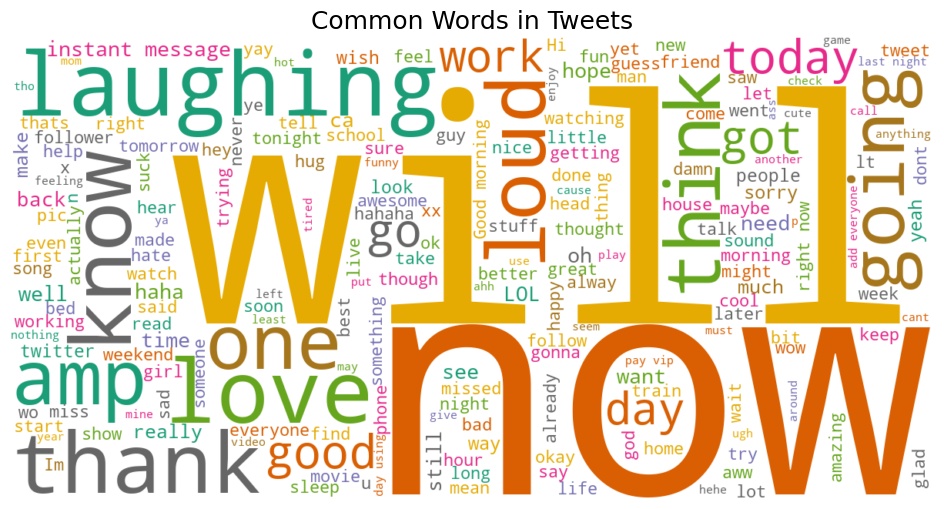

In [73]:
wordcloud = WordCloud(
    max_words=200,
    background_color="white",
    colormap="Dark2",
    width=1200,
    height=600
).generate(text_for_wc)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Tweets", fontsize=18)
plt.show()

## 4. Machine Learning Model
### 4.1 Features (X) and Target (y)
### 4.2 Train/Test Split
### 4.3 Model Training
### 4.4 Evaluation Metrics + Visualizations  
# ____________________________________________________________________________________________________________

#### 4.1 Features (X) and Target (y)

In [76]:
texts = df["ctext"].fillna("").astype(str).tolist()
y_true = df["sentiment"]

#### 4.2 Train/Test Split

In [79]:
X, _, y, _ = train_test_split(
    df["ctext"],
    df["sentiment"],
    train_size=50000,
    random_state=42,
    stratify=df["sentiment"]
)

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
y_train = y_train.astype(str).map({"0": "negative", "1": "positive"})
y_test  = y_test.astype(str).map({"0": "negative", "1": "positive"})

print(y_test.value_counts())

sentiment
positive    5758
negative    4242
Name: count, dtype: int64


In [82]:
def evaluate_model(y_true, y_pred, model_name):
    labels = ["negative", "positive"]
    print(f"\n=== {model_name} ===")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred, labels=labels))

#### 4.3 Model Training
##### Model 1

In [83]:
model_bert = pipeline(
    "text-classification",
    model="Praveen-R/Tweet_sentiment_analysis_with_BERT",
    device=-1
)

Device set to use cpu


In [84]:
res_bert = model_bert(X_test.tolist(), batch_size=32, truncation=True)

In [85]:
label_map_bert = {"LABEL_0": "negative", "LABEL_1": "neutral", "LABEL_2": "positive"}
y_pred_bert_3 = [label_map_bert[r["label"]] for r in res_bert]

In [86]:
y_pred_bert = ["positive" if p in {"positive", "neutral"} else "negative"
               for p in y_pred_bert_3]

##### Model 2

In [87]:
model_roberta = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    device=-1
)

Device set to use cpu


In [88]:
res_roberta = model_roberta(X_test.tolist(), batch_size=32, truncation=True,max_length=128)

KeyboardInterrupt: 

In [ ]:
label_map_roberta = {"LABEL_0": "negative", "LABEL_1": "neutral", "LABEL_2": "positive"}
y_pred_roberta_3 = [label_map_roberta[r["label"]] for r in res_roberta]

In [ ]:
y_pred_roberta = ["positive" if p in {"positive", "neutral"} else "negative" for p in y_pred_roberta_3]

##### Model 3

In [ ]:
model_bertweet_sentiment = pipeline(
    "text-classification",
    model="finiteautomata/bertweet-base-sentiment-analysis"
)

In [ ]:
res_bertweet = model_bertweet_sentiment(X_test.tolist(), batch_size=32, truncation=True, max_length=128)

In [ ]:
label_map_bertweet = {"NEG": "negative", "NEU": "neutral", "POS": "positive"}
y_pred_bertweet_3 = [label_map_bertweet[r["label"]] for r in res_bertweet]

In [ ]:
y_pred_bertweet = ["positive" if p in {"positive", "neutral"} else "negative" for p in y_pred_bertweet_3]

In [ ]:
#Logistic Regression classifier using TF-IDF features
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

In [ ]:
y_pred_tfidf = lr.predict(X_test_tfidf)

#### 4.4 Evaluation Metrics + Visualizations 

In [ ]:
#evaluation : classification_report and confusion_matrix
evaluate_model(y_test, y_pred_bert, "BERT (Praveen-R) - Binary")

In [ ]:
evaluate_model(y_test, y_pred_roberta, "RoBERTa (Twitter) - Binary")

In [ ]:
evaluate_model(y_test, y_pred_bertweet,"BERTweet (FiniteAutomata) - Binary")

In [ ]:
evaluate_model(y_test, y_pred_tfidf,"Logistic Regression classifier using TF-IDF features")

In [ ]:
y_true = y_test
labels_bin = ["negative", "positive"]

In [ ]:
cm_bert = confusion_matrix(y_true, y_pred_bert, labels=labels_bin)

In [ ]:
cm_roberta = confusion_matrix(y_true, y_pred_roberta, labels=labels_bin)

In [ ]:
cm_bertweet = confusion_matrix(y_true, y_pred_bertweet, labels=labels_bin)

In [ ]:
cm_Logistic=confusion_matrix(y_true, y_pred_tfidf, labels=labels_bin)

In [ ]:
def plot_cm(cm, title):
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=labels_bin,
                yticklabels=labels_bin,
                cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(cm_bert, "BERT Confusion Matrix")
plot_cm(cm_roberta, "RoBERTa Confusion Matrix")
plot_cm(cm_bertweet, "bertweet Confusion Matrix")
plot_cm(cm_Logistic, "Logistic Regression Matrix")

In [ ]:
print(classification_report(y_test, y_pred_tfidf, labels=["negative","positive"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tfidf, labels=["negative","positive"]))